# This is a visualisation of the first Prometheus Capital Weekly Quant Radar (WQR_1).
* Compares the simple equal-weighted 1/n portfolio with Markowitz mean-variance optimisation.
* Shows how estimation error in expected returns and covariances can make optimised portfolios unstable.
* Highlights why 1/n can remain a strong out-of-sample benchmark despite its simplicity

Import relevant libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Load dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Prometheus/WQR/dataset_for_portfolio_construction.csv")

Data cleaning

In [3]:
# ==============================================================================
# DATA CLEANING
# ==============================================================================
# Set date
df["date"] = pd.to_datetime(df["date"])

# Handle nan in data
df = df[df[["PERMNO", "date", "TICKER", "PRC", "sprtrn"]].notna()]

# Creating returns
df = df.sort_values(by=["PERMNO", "TICKER", "date"])
df["returns"] = df["PRC"].pct_change()

# Drop duplicates
df = df.drop_duplicates(subset=["date", "PERMNO", "TICKER"])

# Create columns for each TICKER with accompanying returns
df = df.pivot(
    index=["date", "sprtrn"],
    columns="TICKER",
    values="returns")

df.columns.name = None
df = df.reset_index()

# Keep only dates after 2000
df = df[df["date"] >= "2000-01-01"]

# Rename "sprtrn" to "market"
df = df.rename(columns={"sprtrn" : "Market"})

Shared functions

In [4]:
# ==============================================================================
# SHARED FUNCTIONS
# ==============================================================================
# Markowitz optimiser
def optimize_markowitz(mu, sigma, bounds=(0, 1)):
    n = len(mu)

    def negative_sharpe(weights):
        portfolio_return = weights @ mu
        portfolio_vol = np.sqrt(weights @ sigma @ weights)

        if portfolio_vol == 0:
            return 1e10

        return -portfolio_return / portfolio_vol

    constraints = ({
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1})

    bounds = [bounds] * n
    initial_weights = np.ones(n) / n

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints)

    if not result.success:
        return initial_weights

    return result.x

# Sharpe ratio
def annual_sharpe(return_series, periods_per_year=252):
    annual_return = return_series.mean() * periods_per_year
    annual_volatility = return_series.std() * np.sqrt(periods_per_year)

    if annual_volatility == 0:
        return np.nan

    return annual_return / annual_volatility

In-sample performance of 1/n and Markowitz portfolios
* Fixed split 70/30.

           In-sample Sharpe  Out-of-sample Sharpe
1/n                0.485732              0.662268
Markowitz          0.589539              0.418240
Market             0.244457              0.715480


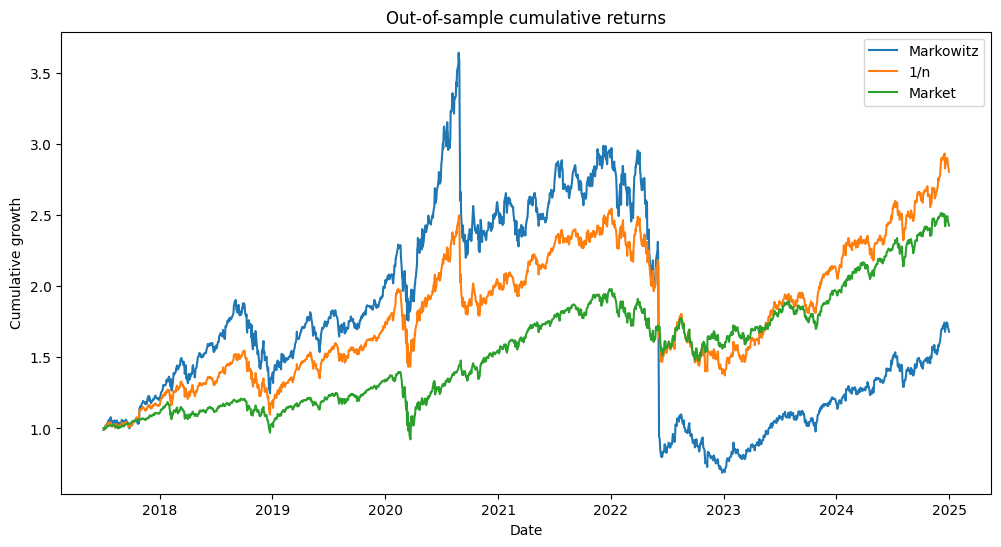

In [8]:
# ==============================================================================
# 1. SETUP
# ==============================================================================
universe = ["AAPL", "AMZN", "IBM", "MSFT", "Market"]

stock_cols = universe[:-1]
market_col = universe[-1]

returns = df[["date"] + stock_cols + [market_col]].dropna().reset_index(drop=True)

R = returns[stock_cols]
dates = returns["date"]

# ==============================================================================
# 2. MAIN ENGINE
# ==============================================================================
split_index = int(len(returns) * 0.70)

in_sample = returns.iloc[:split_index].copy()
out_sample = returns.iloc[split_index:].copy()

R_in = in_sample[stock_cols]
R_out = out_sample[stock_cols]

# Estimating Markowitz, using in-sample data
mu_in = R_in.mean().values
sigma_in = R_in.cov().values

w_markowitz = optimize_markowitz(mu_in, sigma_in)

w_equal = np.ones(len(stock_cols)) / len(stock_cols)

# ==============================================================================
# 3. VISUALISATION ENGINE
# ==============================================================================
# In-sample metrics
in_sample_results = pd.DataFrame({
    "date": in_sample["date"],
    "markowitz": R_in.values @ w_markowitz,
    "equal_weight": R_in.values @ w_equal,
    "market": in_sample[market_col].values})

# Out-of-sample metrics
out_sample_results = pd.DataFrame({
    "date": out_sample["date"],
    "markowitz": R_out.values @ w_markowitz,
    "equal_weight": R_out.values @ w_equal,
    "market": out_sample[market_col].values})

# Performance across subsets
performance = pd.DataFrame({
    "In-sample Sharpe": {
        "1/n": annual_sharpe(in_sample_results["equal_weight"]),
        "Markowitz": annual_sharpe(in_sample_results["markowitz"]),
        "Market": annual_sharpe(in_sample_results["market"])},
    "Out-of-sample Sharpe": {
        "1/n": annual_sharpe(out_sample_results["equal_weight"]),
        "Markowitz": annual_sharpe(out_sample_results["markowitz"]),
        "Market": annual_sharpe(out_sample_results["market"])}})

print(performance)

# Graphs
out_sample_plot = out_sample_results.copy()

out_sample_plot["Markowitz"] = (1 + out_sample_plot["markowitz"]).cumprod()
out_sample_plot["1/n"] = (1 + out_sample_plot["equal_weight"]).cumprod()
out_sample_plot["Market"] = (1 + out_sample_plot["market"]).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(out_sample_plot["date"], out_sample_plot["Markowitz"], label="Markowitz")
plt.plot(out_sample_plot["date"], out_sample_plot["1/n"], label="1/n")
plt.plot(out_sample_plot["date"], out_sample_plot["Market"], label="Market")

plt.title("Out-of-sample cumulative returns")
plt.xlabel("Date")
plt.ylabel("Cumulative growth")
plt.legend()
plt.show()

In-sample performance of 1/n and Markowitz portfolios
* 70/30 split.
* Expanding-window backtest.

           Out-of-sample Sharpe
1/n                    0.662268
Markowitz              0.356212
Market                 0.715480
        date      AAPL      AMZN           IBM          MSFT
0 2017-07-03  0.385199  0.614801  7.520421e-18  1.612751e-17
1 2018-07-03  0.371703  0.628297  0.000000e+00  0.000000e+00
2 2019-07-05  0.371252  0.628748  0.000000e+00  3.707971e-17
3 2020-07-06  0.402176  0.597824  4.907371e-17  0.000000e+00
4 2021-07-06  0.307941  0.671654  1.149254e-17  2.040511e-02
5 2022-07-06  0.413106  0.445400  4.716279e-18  1.414938e-01
6 2023-07-07  0.410470  0.407184  2.211772e-17  1.823456e-01
7 2024-07-09  0.382634  0.404397  0.000000e+00  2.129694e-01


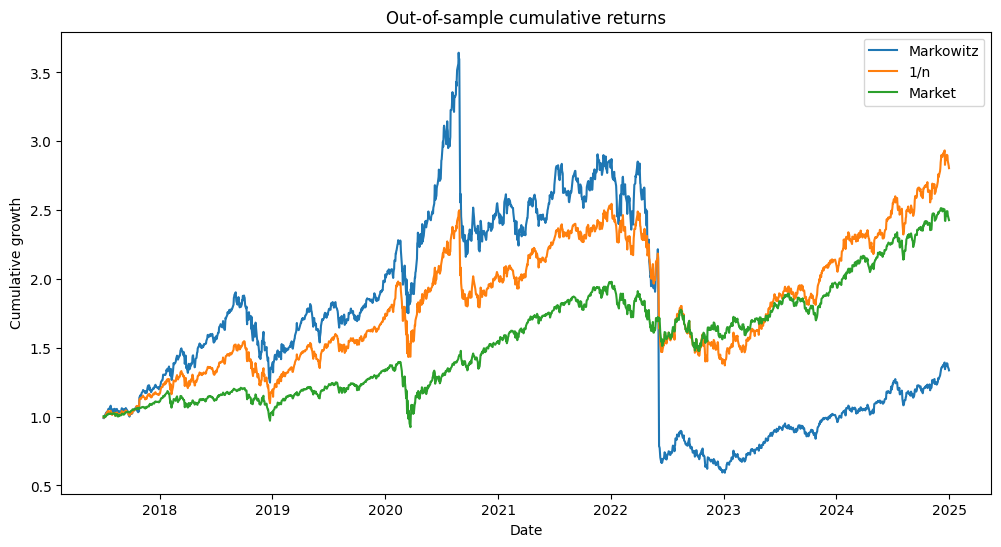

In [11]:
# ==============================================================================
# 1. SETUP
# ==============================================================================
universe = ["AAPL", "AMZN", "IBM", "MSFT", "Market"]

stock_cols = universe[:-1]
market_col = universe[-1]

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

returns = df[["date"] + stock_cols + [market_col]].dropna().reset_index(drop=True)

R = returns[stock_cols]

w_equal = np.ones(len(stock_cols)) / len(stock_cols)

# ==============================================================================
# 2. MAIN ENGINE
# ==============================================================================
initial_train_size = int(len(returns) * 0.70)
rebalance_frequency = 252

all_oos_results = []
weight_history = []

start = initial_train_size

while start < len(returns):

    end = min(start + rebalance_frequency, len(returns))

    # Expanding in-sample window
    train_data = returns.iloc[:start].copy()
    R_train = train_data[stock_cols]

    # 1-year out-of-sample window
    test_data = returns.iloc[start:end].copy()
    R_test = test_data[stock_cols]

    # Estimating Markowitz, using in-sample data
    mu_train = R_train.mean().values
    sigma_train = R_train.cov().values

    w_markowitz = optimize_markowitz(mu_train, sigma_train)

    test_results = pd.DataFrame({
        "date": test_data["date"].values,
        "markowitz": R_test.values @ w_markowitz,
        "equal_weight": R_test.values @ w_equal,
        "market": test_data[market_col].values})

    all_oos_results.append(test_results)

    weight_history.append(
        pd.DataFrame({
            "date": [test_data["date"].iloc[0]],
            **{ticker: [weight] for ticker, weight in zip(stock_cols, w_markowitz)}}))

    start = end

# ==============================================================================
# 3. VISUALISATION ENGINE
# ==============================================================================
out_sample_results = pd.concat(all_oos_results, ignore_index=True)

weights = pd.concat(weight_history, ignore_index=True)

performance = pd.DataFrame({
    "Out-of-sample Sharpe": {
        "1/n": annual_sharpe(out_sample_results["equal_weight"]),
        "Markowitz": annual_sharpe(out_sample_results["markowitz"]),
        "Market": annual_sharpe(out_sample_results["market"])}})

print(performance)

print(weights)

# Graphs
out_sample_plot = out_sample_results.copy()

out_sample_plot["Markowitz"] = (1 + out_sample_plot["markowitz"]).cumprod()
out_sample_plot["1/n"] = (1 + out_sample_plot["equal_weight"]).cumprod()
out_sample_plot["Market"] = (1 + out_sample_plot["market"]).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(out_sample_plot["date"], out_sample_plot["Markowitz"], label="Markowitz")
plt.plot(out_sample_plot["date"], out_sample_plot["1/n"], label="1/n")
plt.plot(out_sample_plot["date"], out_sample_plot["Market"], label="Market")

plt.title("Out-of-sample cumulative returns")
plt.xlabel("Date")
plt.ylabel("Cumulative growth")
plt.legend()
plt.show()

# Results
* Consistent with WQR_1, these graphs show that the simple 1/n allocation rule remains a highly competitive benchmark relative to actively managed mean-variance portfolios.
* While the Markowitz portfolio achieves a stronger in-sample Sharpe ratio, this advantage weakens considerably out-of-sample, where estimation error in expected returns causes the optimiser to overfit historical noise rather than persistent return signals.
* This highlights the central message of the radar: theoretical optimality does not automatically translate into realised performance when portfolio inputs are estimated imperfectly.